# Week 5 — Feature Extraction

This notebook covers the second project milestone:
- Load the RAVDESS metadata table from notebook 01
- Define a feature extraction pipeline using `librosa`
- Extract 194 features per audio file (MFCCs, delta MFCCs, chroma, spectral stats)
- Visualize sample waveform, MFCC heatmap, and per-emotion feature distributions
- Save the full feature matrix to `outputs/features.csv` for use in classification

In [1]:
import os
import time

import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

sns.set_theme(style='whitegrid')

## 1. Load Metadata

We re-use the metadata CSV saved by notebook 01 — it gives us the filepath and emotion label for every file.

In [2]:
df = pd.read_csv('../outputs/metadata.csv')
print(f'Loaded {len(df)} files across {df["emotion"].nunique()} emotion classes')
df.head()

Loaded 2452 files across 8 emotion classes


,filepath,filename,modality,channel,emotion_id,emotion,intensity,statement,repetition,actor,gender
0,../../data\Actor_01\03-01-01-01-01-01-01.wav,03-01-01-01-01-01-01.wav,3,speech,1,neutral,normal,1,1,1,male
1,../../data\Actor_01\03-01-01-01-01-02-01.wav,03-01-01-01-01-02-01.wav,3,speech,1,neutral,normal,1,2,1,male
2,../../data\Actor_01\03-01-01-01-02-01-01.wav,03-01-01-01-02-01-01.wav,3,speech,1,neutral,normal,2,1,1,male
3,../../data\Actor_01\03-01-01-01-02-02-01.wav,03-01-01-01-02-02-01.wav,3,speech,1,neutral,normal,2,2,1,male
4,../../data\Actor_01\03-01-02-01-01-01-01.wav,03-01-02-01-01-01-01.wav,3,speech,2,calm,normal,1,1,1,male


## 2. Feature Extraction Function

For each WAV file we extract time-series features using librosa, then summarize each feature
track with **mean** and **standard deviation** across time frames.  This converts a variable-length
audio signal into a fixed-length feature vector.

| Feature group | Description | Coefficients | Vectors (mean+std) |
|---|---|---|---|
| MFCCs | Mel-Frequency Cepstral Coefficients — compact spectral envelope | 40 | 80 |
| Delta MFCCs | First-order derivative of MFCCs — captures temporal dynamics | 40 | 80 |
| Chroma | Pitch-class energy (C, C#, …, B) — harmonic content | 12 | 24 |
| ZCR | Zero-Crossing Rate — proxy for noisiness / voicing | 1 | 2 |
| RMS | Root-Mean-Square energy — loudness | 1 | 2 |
| Spectral centroid | Brightness of the sound | 1 | 2 |
| Spectral bandwidth | Spread around the centroid | 1 | 2 |
| Spectral roll-off | Frequency below which 85% of energy lies | 1 | 2 |

**Total: 194 features per file.**

In [3]:
def extract_features(filepath, sr=22050, n_mfcc=40, n_chroma=12):
    """Return a flat dict of 194 summary features for one WAV file."""
    y, sr = librosa.load(filepath, sr=sr)
    features = {}

    # --- MFCCs + delta MFCCs ---
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    delta = librosa.feature.delta(mfcc)
    for i in range(n_mfcc):
        features[f'mfcc_{i+1:02d}_mean'] = float(np.mean(mfcc[i]))
        features[f'mfcc_{i+1:02d}_std']  = float(np.std(mfcc[i]))
        features[f'dmfcc_{i+1:02d}_mean'] = float(np.mean(delta[i]))
        features[f'dmfcc_{i+1:02d}_std']  = float(np.std(delta[i]))

    # --- Chroma ---
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_chroma=n_chroma)
    for i in range(n_chroma):
        features[f'chroma_{i+1:02d}_mean'] = float(np.mean(chroma[i]))
        features[f'chroma_{i+1:02d}_std']  = float(np.std(chroma[i]))

    # --- ZCR ---
    zcr = librosa.feature.zero_crossing_rate(y)
    features['zcr_mean'] = float(np.mean(zcr))
    features['zcr_std']  = float(np.std(zcr))

    # --- RMS energy ---
    rms = librosa.feature.rms(y=y)
    features['rms_mean'] = float(np.mean(rms))
    features['rms_std']  = float(np.std(rms))

    # --- Spectral features ---
    sc = librosa.feature.spectral_centroid(y=y, sr=sr)
    features['spectral_centroid_mean'] = float(np.mean(sc))
    features['spectral_centroid_std']  = float(np.std(sc))

    sb = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    features['spectral_bandwidth_mean'] = float(np.mean(sb))
    features['spectral_bandwidth_std']  = float(np.std(sb))

    sro = librosa.feature.spectral_rolloff(y=y, sr=sr)
    features['spectral_rolloff_mean'] = float(np.mean(sro))
    features['spectral_rolloff_std']  = float(np.std(sro))

    return features

### Quick sanity check — verify feature count on one file

In [4]:
sample_feats = extract_features(df['filepath'].iloc[0])
print(f'Features extracted: {len(sample_feats)}')
print(list(sample_feats.keys())[:10], '...')

Features extracted: 194
['mfcc_01_mean', 'mfcc_01_std', 'dmfcc_01_mean', 'dmfcc_01_std', 'mfcc_02_mean', 'mfcc_02_std', 'dmfcc_02_mean', 'dmfcc_02_std', 'mfcc_03_mean', 'mfcc_03_std'] ...


## 3. Extract Features for All 2,452 Files

This loop iterates over every row in the metadata table, calls `extract_features`, appends
the label columns, and collects the results.  On a typical laptop this takes ~3–5 minutes.

In [5]:
LABEL_COLS = ['filename', 'emotion', 'emotion_id', 'actor', 'gender', 'channel']

records = []
errors  = []

t0 = time.time()
for _, row in tqdm(df.iterrows(), total=len(df), desc='Extracting features'):
    try:
        feats = extract_features(row['filepath'])
        for col in LABEL_COLS:
            feats[col] = row[col]
        records.append(feats)
    except Exception as exc:
        errors.append((row['filepath'], str(exc)))

elapsed = time.time() - t0
print(f'\nDone: {len(records)} files in {elapsed:.1f}s  ({elapsed/len(records):.2f}s/file)')
if errors:
    print(f'Errors ({len(errors)}):')
    for path, msg in errors[:5]:
        print(f'  {path}: {msg}')

Extracting features:   0%|          | 0/2452 [00:00<?, ?it/s]


Done: 2452 files in 216.7s  (0.09s/file)


In [6]:
features_df = pd.DataFrame(records)

feature_cols = [c for c in features_df.columns if c not in LABEL_COLS]

print(f'Feature matrix : {features_df[feature_cols].shape}')
print(f'  rows  = {len(features_df)} (one per audio file)')
print(f'  cols  = {len(feature_cols)} features')
print(f'\nLabel distribution:')
print(features_df['emotion'].value_counts().to_string())

features_df[feature_cols].describe().T.head(10)

Feature matrix : (2452, 194)
  rows  = 2452 (one per audio file)
  cols  = 194 features

Label distribution:
emotion
calm         376
happy        376
sad          376
angry        376
fearful      376
disgust      192
surprised    192
neutral      188


,count,mean,std,min,25%,50%,75%,max
mfcc_01_mean,2452.0,-564.207485,96.250690,-848.593628,-630.294037,-5.659717e+02,-497.480446,-303.908295
mfcc_01_std,2452.0,169.038115,19.221406,111.571449,155.897083,1.698535e+02,182.942539,223.598480
dmfcc_01_mean,2452.0,0.021981,0.233014,-1.617960,-0.006349,4.029598e-07,0.024262,3.424814
dmfcc_01_std,2452.0,15.078159,2.743825,7.130456,13.420858,1.511267e+01,16.752528,25.200161
mfcc_02_mean,2452.0,47.122571,17.082199,-5.350825,33.461338,4.794649e+01,60.242690,96.597054
mfcc_02_std,2452.0,52.207241,11.067635,21.570177,43.812680,5.368094e+01,60.113795,82.368599
dmfcc_02_mean,2452.0,0.027582,0.115999,-0.674333,-0.005207,3.350535e-04,0.032566,0.822232
dmfcc_02_std,2452.0,7.444028,1.577148,3.780246,6.264812,7.290337e+00,8.490768,14.036750
mfcc_03_mean,2452.0,-9.861571,13.118204,-55.784222,-18.701810,-1.025065e+01,-0.520961,28.183119
mfcc_03_std,2452.0,29.253616,6.840094,12.084880,24.320040,2.866976e+01,33.383205,54.591423


## 4. Visualizations

### 4a. Sample waveform and MFCC heatmap

Loading one file to see what the raw signal and its MFCC representation look like.

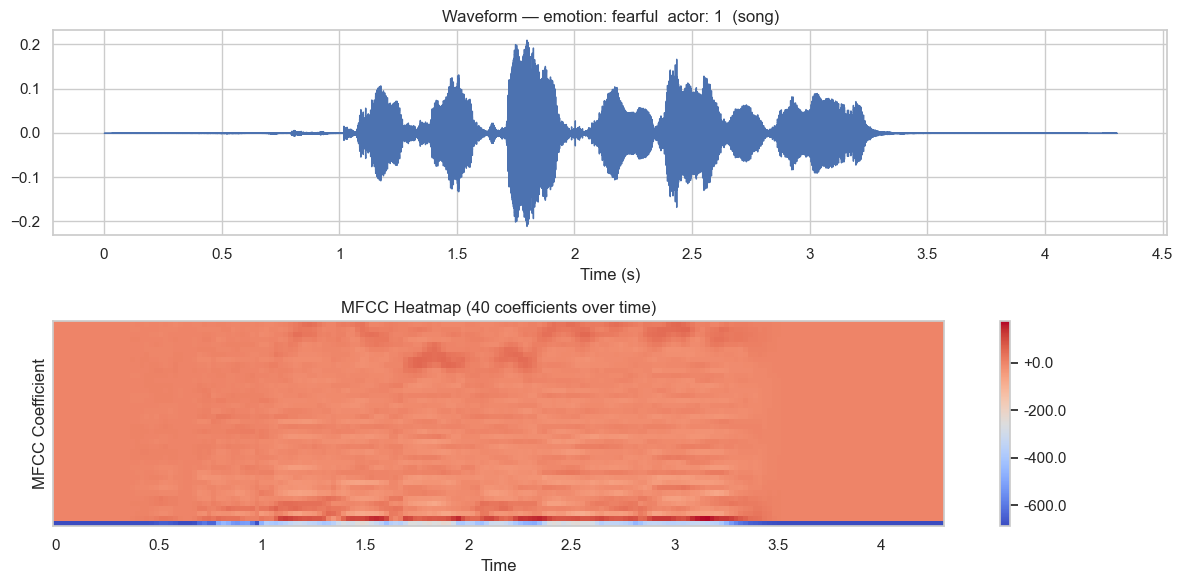

Saved to outputs/sample_mfcc.png


In [7]:
sample_row = df.iloc[100]  # pick a mid-dataset file
y_sample, sr_sample = librosa.load(sample_row['filepath'], sr=22050)
mfcc_sample = librosa.feature.mfcc(y=y_sample, sr=sr_sample, n_mfcc=40)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Waveform
librosa.display.waveshow(y_sample, sr=sr_sample, ax=axes[0])
axes[0].set_title(f'Waveform — emotion: {sample_row["emotion"]}  actor: {sample_row["actor"]}  ({sample_row["channel"]})')
axes[0].set_xlabel('Time (s)')

# MFCC heatmap
img = librosa.display.specshow(mfcc_sample, sr=sr_sample, x_axis='time', ax=axes[1], cmap='coolwarm')
axes[1].set_title('MFCC Heatmap (40 coefficients over time)')
axes[1].set_ylabel('MFCC Coefficient')
fig.colorbar(img, ax=axes[1], format='%+.1f')

plt.tight_layout()
plt.savefig('../outputs/sample_mfcc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/sample_mfcc.png')

### 4b. MFCC 1 mean by emotion

MFCC-1 captures overall spectral energy.  If it varies by emotion class, it will be a useful
discriminative feature.

C:\Users\augus\AppData\Local\Temp\ipykernel_11036\1726834396.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(plot_data, labels=EMOTION_ORDER, notch=False)
C:\Users\augus\AppData\Local\Temp\ipykernel_11036\1726834396.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(plot_data_zcr, labels=EMOTION_ORDER, notch=False)


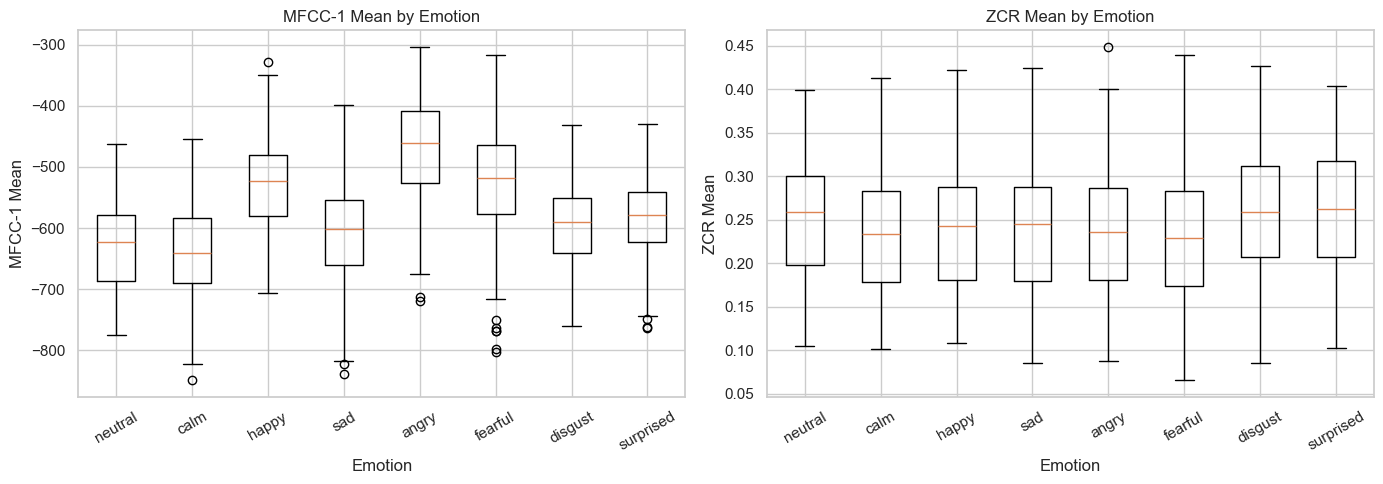

Saved to outputs/feature_by_emotion.png


In [8]:
EMOTION_ORDER = ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot of MFCC-1 mean
plot_data = [features_df.loc[features_df['emotion'] == em, 'mfcc_01_mean'].values for em in EMOTION_ORDER]
axes[0].boxplot(plot_data, labels=EMOTION_ORDER, notch=False)
axes[0].set_title('MFCC-1 Mean by Emotion')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('MFCC-1 Mean')
axes[0].tick_params(axis='x', rotation=30)

# Box plot of ZCR mean
plot_data_zcr = [features_df.loc[features_df['emotion'] == em, 'zcr_mean'].values for em in EMOTION_ORDER]
axes[1].boxplot(plot_data_zcr, labels=EMOTION_ORDER, notch=False)
axes[1].set_title('ZCR Mean by Emotion')
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('ZCR Mean')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../outputs/feature_by_emotion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/feature_by_emotion.png')

### 4c. Mean MFCC profiles per emotion

Averaging each of the 40 MFCC means across all files of a given emotion gives a compact
spectral fingerprint.  Emotions with very different profiles should be easier to classify.

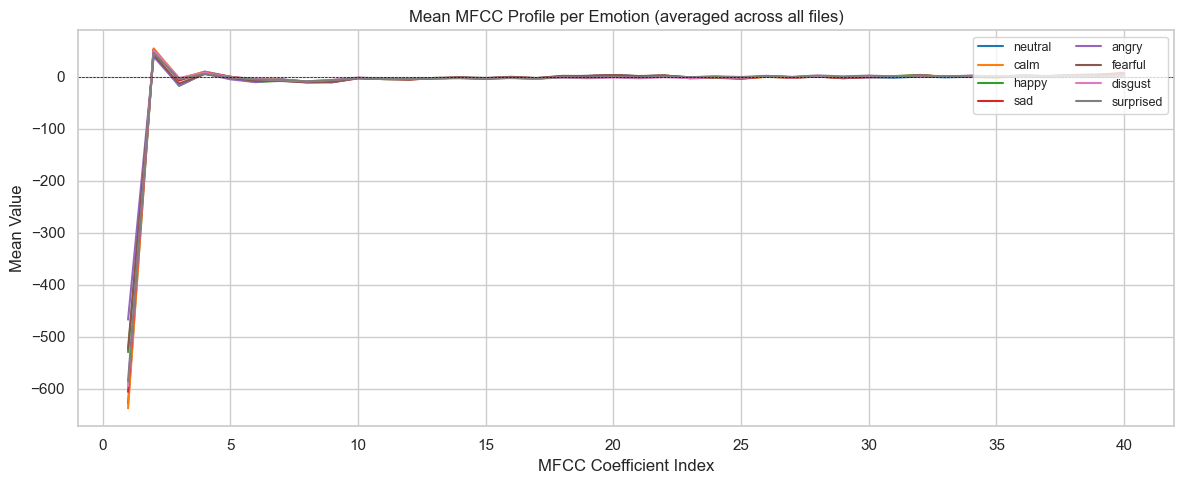

Saved to outputs/mfcc_profiles.png


In [9]:
mfcc_mean_cols = [f'mfcc_{i+1:02d}_mean' for i in range(40)]

fig, ax = plt.subplots(figsize=(12, 5))
palette = sns.color_palette('tab10', len(EMOTION_ORDER))

for emotion, color in zip(EMOTION_ORDER, palette):
    subset = features_df[features_df['emotion'] == emotion]
    profile = subset[mfcc_mean_cols].mean().values
    ax.plot(range(1, 41), profile, label=emotion, color=color, linewidth=1.5)

ax.set_title('Mean MFCC Profile per Emotion (averaged across all files)')
ax.set_xlabel('MFCC Coefficient Index')
ax.set_ylabel('Mean Value')
ax.legend(loc='upper right', ncol=2, fontsize=9)
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.savefig('../outputs/mfcc_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/mfcc_profiles.png')

## 5. Save Feature Matrix

The full feature table (features + labels) is written to `outputs/features.csv`.  Downstream
notebooks will load this file directly — no need to re-run the extraction.

In [10]:
os.makedirs('../outputs', exist_ok=True)
features_df.to_csv('../outputs/features.csv', index=False)

print(f'Saved: outputs/features.csv')
print(f'  Shape       : {features_df.shape}')
print(f'  Feature cols: {len(feature_cols)}')
print(f'  Label col   : emotion ({features_df["emotion"].nunique()} classes)')
print(f'\nFirst few feature columns:')
print(feature_cols[:8])
print('...')
print(f'Last few feature columns:')
print(feature_cols[-6:])

Saved: outputs/features.csv
  Shape       : (2452, 200)
  Feature cols: 194
  Label col   : emotion (8 classes)

First few feature columns:
['mfcc_01_mean', 'mfcc_01_std', 'dmfcc_01_mean', 'dmfcc_01_std', 'mfcc_02_mean', 'mfcc_02_std', 'dmfcc_02_mean', 'dmfcc_02_std']
...
Last few feature columns:
['spectral_centroid_mean', 'spectral_centroid_std', 'spectral_bandwidth_mean', 'spectral_bandwidth_std', 'spectral_rolloff_mean', 'spectral_rolloff_std']
